# Assignment 3: Retrieval-Augmented Generation (RAG) System for Cybersecurity Guidelines

**Course:** Advanced Topics in Artificial Intelligence and Machine Learning
**Student:** Yash Sarda (a1993661)
**Topic:** Phishing Detection, Incident Response & Vulnerability Management
**LLM:** `mistralai/Mistral-7B-Instruct-v0.2` (open-source, Apache 2.0)
**Embedding Model:** `sentence-transformers/all-MiniLM-L6-v2`
**Vector Store:** FAISS (IndexFlatIP)
**Evaluation:** RAGAS-aligned metrics — Faithfulness, Answer Relevance, Context Relevance

---

## Abstract

This notebook presents a domain-specific Retrieval-Augmented Generation (RAG) system that generates actionable cybersecurity guidelines for practitioners. The system retrieves relevant passages from a curated knowledge base assembled from 10 authoritative sources and uses Mistral-7B-Instruct-v0.2, an open-source instruction-tuned language model, to synthesise practitioner-ready guidelines. We evaluate the system using three RAGAS-aligned metrics (faithfulness, answer relevance, and context relevance) across 10 representative practitioner queries, and critically assess the system's trustworthiness, failure modes, and ethical implications for operational deployment.

## 1. Literature Review

### 1.1 Retrieval-Augmented Generation (RAG)

Lewis et al. (2020) introduced RAG as a paradigm for combining the parametric knowledge stored in language model weights with non-parametric retrieval from an external document store. Their architecture demonstrated that grounding LLM generation in retrieved passages significantly reduces hallucination and improves factual accuracy on knowledge-intensive NLP tasks. Critically for our use case, RAG systems can be updated without retraining — the knowledge base can be refreshed as cybersecurity standards evolve — which makes them far more practical for rapidly changing domains like cybersecurity than fine-tuned-only approaches.

Karpukhin et al. (2020) introduced Dense Passage Retrieval (DPR), demonstrating that bi-encoder dense retrieval substantially outperforms traditional BM25 sparse retrieval for open-domain question answering, particularly for semantically rich queries where keyword overlap between query and answer is low. This motivates the dense retrieval approach adopted here. Reimers & Gurevych (2019) further advanced dense retrieval with Sentence-BERT, producing semantically rich sentence embeddings optimised for cosine-similarity-based search — the direct predecessor of the `all-MiniLM-L6-v2` model used in this system.

### 1.2 RAG for Cybersecurity

Zhao et al. (2025) developed CyberBOT, a RAG system grounded in a cybersecurity ontology for educational use. Their key contribution was ontological constraint during retrieval to improve factual grounding, achieving higher faithfulness scores compared to naive dense retrieval — particularly on adversarial or ambiguous queries. This finding directly informed the design of our knowledge base, which draws exclusively from authoritative, structured standards rather than open-web sources.

Blefari et al. (2025) presented CyberRAG, an agentic RAG system for classifying and reporting cyber-attacks. Their multi-step retrieval pipeline with agent-directed query rewriting improved context relevance scores by up to 18% over single-pass retrieval. While this system uses single-pass retrieval for simplicity, the CyberRAG results motivate query rewriting as a future improvement (discussed in Section 8).

### 1.3 Evaluation with RAGAS

Es et al. (2024) proposed RAGAS (Retrieval Augmented Generation Assessment), a reference-free evaluation framework that assesses RAG systems along three axes: **faithfulness** (is the answer grounded in retrieved context, with no hallucinated claims?), **answer relevance** (does the generated answer appropriately address the query?), and **context relevance** (are the retrieved passages focused on the query, without excessive noise?). The key innovation is that RAGAS requires no human-annotated ground truth, using LLM-based scoring instead — making it practical for deployment evaluation without large annotation budgets. Sections 6 and 7 implement these three dimensions using proxy metrics calibrated to RAGAS definitions.

### 1.4 Instruction-Tuned Language Models

Jiang et al. (2023) introduced Mistral-7B, a 7-billion-parameter language model that outperforms
LLaMA-2-13B on most benchmarks despite being nearly half the size, through architectural
innovations including grouped-query attention and sliding window attention. The instruction-tuned
variant, Mistral-7B-Instruct-v0.2, is fine-tuned on instruction-response pairs and follows
structured prompts reliably using the `[INST] ... [/INST]` chat template. Loaded in 4-bit
NormalFloat (NF4) quantization via bitsandbytes, it consumes approximately 5 GB VRAM —
making it practical for Colab's T4 GPU while delivering substantially stronger generation
quality than smaller encoder-decoder models (e.g., Flan-T5) on open-ended multi-sentence tasks.

### 1.5 Positioning of This Work

This system extends domain-specific RAG to an operational practitioner-facing cybersecurity setting. Unlike CyberBOT (educational) and CyberRAG (attack classification), this system targets operational practitioners who need actionable, source-grounded guidelines during or before security events. This distinction imposes stricter requirements: the system must be faithful (no hallucinated controls), actionable (specific enough to implement), and transparent (source attribution). These requirements are directly evaluated in Sections 6–8.

## 2. System Architecture & Design Justification

### 2.1 Pipeline Overview

| Stage | Component | Choice |
|---|---|---|
| Document Store | 10 NIST PDFs | SP 800-61r2, 800-40r4, 800-207, 800-63B, CSF 2.0, 800-177r1, 800-171r2, 800-53r5, 800-115, 800-137 |
| Text Extraction | pdfplumber | Accurate layout-aware PDF parsing |
| Chunking | Sliding window | 200 words, 30-word overlap |
| Embedding Model | all-MiniLM-L6-v2 | 384-dim dense embeddings |
| Vector Index | FAISS IndexFlatIP | Exact cosine similarity search |
| LLM | Mistral-7B-Instruct-v0.2 | 4-bit quantized instruction-following model |
| Metrics | Proxy (manual) | Context relevance, answer relevance, faithfulness |

### 2.2 Retrieval Design

Dense retrieval using `sentence-transformers/all-MiniLM-L6-v2` encodes both queries and document chunks into a shared 384-dimensional semantic space. FAISS `IndexFlatIP` performs exact inner-product search over L2-normalised vectors, which is equivalent to cosine similarity. Top-k=3 chunks are retrieved per query, with a diversity filter ensuring chunks span different source documents where possible.

### 2.3 Chunking Strategy

A sliding window of 200 words with 30-word overlap balances context coherence and retrieval granularity. Chunks shorter than 50 words or containing boilerplate (withdrawn notices, table-of-contents fragments, numeric-heavy pages) are removed during a post-processing quality filter, yielding 2,626 clean chunks across 10 documents.

### 2.4 LLM Selection: Mistral-7B-Instruct-v0.2

Mistral-7B-Instruct-v0.2 (Jiang et al., 2023) is selected for the generation stage. Key reasons:

- **Instruction-following**: trained with supervised fine-tuning on instruction-response pairs, making it reliably follow structured prompts (e.g., "provide exactly 3 recommendations")
- **Memory efficiency**: loaded in 4-bit NormalFloat (NF4) via bitsandbytes, consuming ~5 GB VRAM — well within the 15 GB available on Colab T4
- **Generation quality**: outperforms encoder-decoder models (e.g., Flan-T5) on open-ended generation tasks requiring multi-sentence, coherent outputs
- **Prompt format**: uses `[INST] ... [/INST]` chat template, enabling clean separation of system context, retrieved passages, and the user query

### 2.5 Metrics Design (RAGAS-Aligned Proxies)

Rather than using the RAGAS library, three proxy metrics are implemented manually:

| Metric | RAGAS Analogue | Implementation |
|---|---|---|
| Context Relevance | context_precision | Cosine similarity between query embedding and retrieved chunk embeddings |
| Answer Relevance | answer_relevance | Cosine similarity between query embedding and answer embedding |
| Faithfulness | faithfulness | Token-level F1 overlap between answer tokens and retrieved context tokens |

In [1]:
#Install Dependencies
!pip install -q sentence-transformers faiss-cpu
!pip install -q transformers accelerate sentencepiece bitsandbytes
!pip install -q pandas numpy matplotlib seaborn scikit-learn
!pip install -q pdfplumber
print("All dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 126.7 MB/s eta 0:00:00
All dependencies installed.


In [2]:
# Cell 04 — Imports & Device Setup
import os, re, gc, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
import faiss

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected. Switch runtime to T4.")

print(f"Device: {DEVICE}")

GPU: Tesla T4
VRAM: 15.6 GB
Device: cuda


## 3. Knowledge Base Construction

The knowledge base is assembled from content derived from the following authoritative public-domain sources:

| Source | Topic Coverage |
|--------|---------------|
| NIST SP 800-61 Rev 2 | Incident response lifecycle, CSIRT structure, post-incident analysis |
| NIST SP 800-40 Rev 4 | Patch and vulnerability management |
| NIST SP 800-207 | Zero Trust Architecture |
| NIST SP 800-63B | Authentication, MFA, digital identity guidelines |
| NIST CSF 2.0 | Security awareness, endpoint security, governance |
| NIST SP 800-177 Rev 1 | Email security, anti-phishing technical controls |
| NIST SP 800-171 Rev 2 | Access control, network monitoring, supply chain security |
| NIST SP 800-53 Rev 5 | Security and privacy controls catalogue |
| NIST SP 800-115 | Technical guide to information security testing |
| NIST SP 800-137 | Continuous monitoring of information systems |

The knowledge base is drawn from 10 authoritative NIST publications totalling over 250,000 words, chunked into 200-word passages with 30-word overlap, targeting ≥2,000 addressable question contexts

In [3]:
#Knowledge Base — Source Documents
import os
import subprocess
SOURCES = {
    "nist_800_61.pdf":  "https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-61r2.pdf",
    "nist_800_40.pdf":  "https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-40r4.pdf",
    "nist_800_207.pdf": "https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-207.pdf",
    "nist_800_63b.pdf": "https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-63b.pdf",
    "nist_csf_2.pdf":   "https://nvlpubs.nist.gov/nistpubs/CSWP/NIST.CSWP.29.pdf",
    "nist_800_177.pdf": "https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-177r1.pdf",
    "nist_800_171.pdf": "https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-171r2.pdf",
    "nist_800_53.pdf":  "https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-53r5.pdf",
    "nist_800_115.pdf": "https://nvlpubs.nist.gov/nistpubs/Legacy/SP/nistspecialpublication800-115.pdf",
    "nist_800_137.pdf": "https://nvlpubs.nist.gov/nistpubs/Legacy/SP/nistspecialpublication800-137.pdf",
}

os.makedirs("sources", exist_ok=True)

for filename, url in SOURCES.items():
    filepath = f"sources/{filename}"
    if os.path.exists(filepath) and os.path.getsize(filepath) > 10000:
        size_mb = os.path.getsize(filepath) / 1e6
        print(f"Already exists: {filename} ({size_mb:.1f} MB)")
        continue
    print(f"Downloading {filename} ...")
    result = subprocess.run(
        ["wget", "-q", "-O", filepath, url],
        capture_output=True, text=True
    )
    if os.path.exists(filepath) and os.path.getsize(filepath) > 10000:
        size_mb = os.path.getsize(filepath) / 1e6
        print(f"  ✓ {filename} ({size_mb:.1f} MB)")
    else:
        print(f"  ✗ Failed: {filename}")
        os.remove(filepath) if os.path.exists(filepath) else None

print("\nAll files in sources/:")
for f in sorted(os.listdir("sources")):
    size_mb = os.path.getsize(f"sources/{f}") / 1e6
    print(f"  {f} ({size_mb:.1f} MB)")

  ✓ nist_800_61.pdf (1.7 MB)
  ✓ nist_800_40.pdf (0.6 MB)
  ✓ nist_800_207.pdf (1.0 MB)
  ✓ nist_800_63b.pdf (1.5 MB)
  ✓ nist_csf_2.pdf (1.5 MB)
  ✓ nist_800_177.pdf (1.7 MB)
  ✓ nist_800_171.pdf (1.5 MB)
  ✓ nist_800_53.pdf (6.1 MB)
  ✓ nist_800_115.pdf (0.5 MB)
  ✓ nist_800_137.pdf (1.0 MB)

All files in sources/:
  nist_800_115.pdf (0.5 MB)
  nist_800_137.pdf (1.0 MB)
  nist_800_171.pdf (1.5 MB)
  nist_800_177.pdf (1.7 MB)
  nist_800_207.pdf (1.0 MB)
  nist_800_40.pdf (0.6 MB)
  nist_800_53.pdf (6.1 MB)
  nist_800_61.pdf (1.7 MB)
  nist_800_63b.pdf (1.5 MB)
  nist_csf_2.pdf (1.5 MB)


In [4]:
#Extract Text from PDFs
!pip install -q pdfplumber
import pdfplumber

SOURCE_MAP = {
    "nist_800_61.pdf":  "NIST SP 800-61 Rev 2",
    "nist_800_40.pdf":  "NIST SP 800-40 Rev 4",
    "nist_800_207.pdf": "NIST SP 800-207",
    "nist_800_63b.pdf": "NIST SP 800-63B",
    "nist_csf_2.pdf":   "NIST CSF 2.0",
    "nist_800_177.pdf": "NIST SP 800-177 Rev 1",
    "nist_800_171.pdf": "NIST SP 800-171 Rev 2",
    "nist_800_53.pdf":  "NIST SP 800-53 Rev 5",
    "nist_800_115.pdf": "NIST SP 800-115",
    "nist_800_137.pdf": "NIST SP 800-137",
}

RAW_DOCUMENTS = []

for filename, source_name in SOURCE_MAP.items():
    filepath = f"sources/{filename}"
    print(f"Extracting: {filename} ...", end=" ")

    try:
        with pdfplumber.open(filepath) as pdf:
            full_text = ""
            for page in pdf.pages:
                text = page.extract_text(x_tolerance=3, y_tolerance=3)
                if text:
                    full_text += text + "\n"

        # Clean up
        full_text = re.sub(r'[^\x00-\x7F]+', ' ', full_text)  # remove non-ASCII
        full_text = re.sub(r'\s+', ' ', full_text).strip()     # collapse whitespace

        RAW_DOCUMENTS.append({
            "source":    source_name,
            "filename":  filename,
            "content":   full_text,
            "num_pages": len(pdf.pages),
            "num_words": len(full_text.split())
        })
        print(f"✓ {len(full_text.split()):,} words")

    except Exception as e:
        print(f"✗ Error: {e}")

print(f"\nTotal documents: {len(RAW_DOCUMENTS)}")
print(f"Total words:     {sum(d['num_words'] for d in RAW_DOCUMENTS):,}")

# Show sample text quality
print("\n--- Sample text (first 300 chars of NIST 800-61) ---")
print(RAW_DOCUMENTS[0]['content'][:300])

Extracting: nist_800_61.pdf ... ✓ 31,627 words
Extracting: nist_800_40.pdf ... ✓ 10,200 words
Extracting: nist_800_207.pdf ... ✓ 22,235 words
Extracting: nist_800_63b.pdf ... ✓ 27,125 words
Extracting: nist_csf_2.pdf ... ✓ 9,369 words
Extracting: nist_800_177.pdf ... ✓ 44,481 words
Extracting: nist_800_171.pdf ... ✓ 36,076 words
Extracting: nist_800_53.pdf ... ✓ 198,390 words
Extracting: nist_800_115.pdf ... ✓ 34,891 words
Extracting: nist_800_137.pdf ... ✓ 29,889 words

Total documents: 10
Total words:     444,283

--- Sample text (first 300 chars of NIST 800-61) ---
Withdrawn NIST Technical Series Publication Warning Notice The attached publication has been withdrawn (archived), and is provided solely for historical purposes. It may have been superseded by another publication (indicated below). Withdrawn Publication Series/Number NIST Special Publication (SP) 8


In [5]:
def chunk_document(doc: dict, chunk_size: int = 200, overlap: int = 30) -> list:
    """
    Split a document into overlapping word-level chunks.
    Args:
        doc       : dict with 'content', 'source', 'filename'
        chunk_size: target chunk size in words
        overlap   : overlapping words between consecutive chunks
    Returns:
        List of chunk dicts
    """
    words = doc['content'].split()
    chunks = []
    start = 0
    chunk_id = 0

    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunk_text = ' '.join(words[start:end])
        chunks.append({
            'chunk_id':   f"{doc['filename'].replace('.pdf','')}_chunk_{chunk_id}",
            'text':       chunk_text,
            'source':     doc['source'],
            'filename':   doc['filename'],
            'word_count': end - start
        })
        chunk_id += 1
        if end == len(words):
            break
        start += chunk_size - overlap
    return chunks

# Chunk all documents
all_chunks = []
for doc in RAW_DOCUMENTS:
    doc_chunks = chunk_document(doc, chunk_size=200, overlap=30)
    all_chunks.extend(doc_chunks)
    print(f"  {doc['source']:<30} → {len(doc_chunks):>4} chunks")

print(f"\nTotal chunks: {len(all_chunks)}")
print(f"Average chunk size: {sum(c['word_count'] for c in all_chunks) / len(all_chunks):.0f} words")
print(f"\nKnowledge base capacity: {len(all_chunks)} addressable question contexts")
print(f"Assignment target (≥2,000): {'✓ MET' if len(all_chunks) >= 2000 else '✗ Not met'}")

# Show a sample chunk
print(f"\n--- Sample Chunk ---")
print(f"ID:     {all_chunks[0]['chunk_id']}")
print(f"Source: {all_chunks[0]['source']}")
print(f"Words:  {all_chunks[0]['word_count']}")
print(f"Text:   {all_chunks[0]['text'][:300]}...")

  NIST SP 800-61 Rev 2           →  186 chunks
  NIST SP 800-40 Rev 4           →   60 chunks
  NIST SP 800-207                →  131 chunks
  NIST SP 800-63B                →  160 chunks
  NIST CSF 2.0                   →   55 chunks
  NIST SP 800-177 Rev 1          →  262 chunks
  NIST SP 800-171 Rev 2          →  213 chunks
  NIST SP 800-53 Rev 5           → 1167 chunks
  NIST SP 800-115                →  206 chunks
  NIST SP 800-137                →  176 chunks

Total chunks: 2616
Average chunk size: 200 words

Knowledge base capacity: 2616 addressable question contexts
Assignment target (≥2,000): ✓ MET

--- Sample Chunk ---
ID:     nist_800_61_chunk_0
Source: NIST SP 800-61 Rev 2
Words:  200
Text:   Withdrawn NIST Technical Series Publication Warning Notice The attached publication has been withdrawn (archived), and is provided solely for historical purposes. It may have been superseded by another publication (indicated below). Withdrawn Publication Series/Number NIST Special Publ

In [6]:
#Filter low quality chunks
FILTER_PHRASES = [
    "withdrawn",
    "superseded",
    "this publication has been",
    "table of contents",
    "list of figures",
    "list of tables",
    "page intentionally left blank",
    "nist technical series publication",
    "warning notice",
]

def is_low_quality(chunk: dict) -> bool:
    text_lower = chunk['text'].lower()
    # Filter if any boilerplate phrase found
    if any(phrase in text_lower for phrase in FILTER_PHRASES):
        return True
    # Filter if chunk has too many numbers (likely TOC or reference list)
    words = chunk['text'].split()
    num_count = sum(1 for w in words if w.replace('.','').replace(',','').isdigit())
    if num_count / len(words) > 0.3:
        return True
    # Filter very short chunks (leftover fragments)
    if chunk['word_count'] < 50:
        return True
    return False


before = len(all_chunks)
all_chunks = [c for c in all_chunks if not is_low_quality(c)]
after = len(all_chunks)

print(f"Chunks before filtering: {before}")
print(f"Chunks removed:          {before - after}")
print(f"Chunks after filtering:  {after}")
print(f"Assignment target (≥2,000): {'✓ MET' if after >= 2000 else '✗ Not met'}")

Chunks before filtering: 2616
Chunks removed:          175
Chunks after filtering:  2441
Assignment target (≥2,000): ✓ MET


In [7]:
#Dense Embeddings and FAISS Vector Store
print("Loading embedding model: all-MiniLM-L6-v2 ...")
embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=DEVICE)
print(f"Embedding dimension: {embed_model.get_sentence_embedding_dimension()}")

# Embed all chunks
print(f"\nEmbedding {len(all_chunks)} chunks ...")
all_texts = [c['text'] for c in all_chunks]
chunk_embeddings = embed_model.encode(
    all_texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

# L2-normalise for cosine similarity via inner product
norms = np.linalg.norm(chunk_embeddings, axis=1, keepdims=True)
chunk_embeddings_norm = chunk_embeddings / norms
print(f"Embeddings shape: {chunk_embeddings_norm.shape}")

# Build FAISS index
EMBED_DIM = chunk_embeddings_norm.shape[1]
faiss_index = faiss.IndexFlatIP(EMBED_DIM)
faiss_index.add(chunk_embeddings_norm.astype('float32'))
print(f"\nFAISS index built")
print(f"  Index type:     IndexFlatIP (exact cosine search)")
print(f"  Vectors stored: {faiss_index.ntotal}")
print(f"  Dimension:      {EMBED_DIM}")

def retrieve(query: str, k: int = 3) -> list:
    """
    Retrieve top-k chunks most relevant to the query.
    Args:
        query: practitioner query string
        k    : number of chunks to retrieve
    Returns:
        List of dicts with text, source, score
    """
    q_emb = embed_model.encode([query], convert_to_numpy=True)
    q_emb_norm = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)
    scores, indices = faiss_index.search(q_emb_norm.astype('float32'), k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            'text':     all_chunks[idx]['text'],
            'source':   all_chunks[idx]['source'],
            'filename': all_chunks[idx]['filename'],
            'chunk_id': all_chunks[idx]['chunk_id'],
            'score':    float(score)
        })
    return results

# Quick test
print("\nTesting retrieval ...")
test = retrieve("How to prevent phishing?", k=3)
for i, r in enumerate(test, 1):
    print(f"  {i}. [{r['score']:.4f}] {r['source']} — {r['chunk_id']}")

Loading embedding model: all-MiniLM-L6-v2 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384

Embedding 2441 chunks ...


/tmp/ipykernel_2844/1840342402.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Embedding dimension: {embed_model.get_sentence_embedding_dimension()}")


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Embeddings shape: (2441, 384)

FAISS index built
  Index type:     IndexFlatIP (exact cosine search)
  Vectors stored: 2441
  Dimension:      384

Testing retrieval ...
  1. [0.5747] NIST SP 800-177 Rev 1 — nist_800_177_chunk_64
  2. [0.5408] NIST SP 800-177 Rev 1 — nist_800_177_chunk_61
  3. [0.5256] NIST SP 800-177 Rev 1 — nist_800_177_chunk_73


In [8]:
#Retrieval Quality Spot-Check
spot_check_queries = [
    "What email authentication protocols prevent phishing?",
    "How should we structure our incident response team?",
    "What are the steps for ransomware recovery?"
]

print("=" * 70)
print("RETRIEVAL QUALITY SPOT-CHECK")
print("=" * 70)

for query in spot_check_queries:
    results = retrieve(query, k=3)
    print(f"\nQuery: {query}")
    print("-" * 60)
    for i, r in enumerate(results, 1):
        print(f"  Rank {i} | Score: {r['score']:.4f} | {r['source']}")
        print(f"         | Chunk: {r['chunk_id']}")
        print(f"         | Preview: {r['text'][:150].strip()}...")
    print()

RETRIEVAL QUALITY SPOT-CHECK

Query: What email authentication protocols prevent phishing?
------------------------------------------------------------
  Rank 1 | Score: 0.6156 | NIST SP 800-177 Rev 1
         | Chunk: nist_800_177_chunk_4
         | Preview: the cost-effective security and privacy of other than national security-related information in federal information systems. e Special Publication 800-...
  Rank 2 | Score: 0.6152 | NIST SP 800-177 Rev 1
         | Chunk: nist_800_177_chunk_50
         | Preview: can protect email messages solely with host-based security, or they can implement a cryptographic layer using S/MIME, OpenPGP, or other algorithms, su...
  Rank 3 | Score: 0.6018 | NIST SP 800-177 Rev 1
         | Chunk: nist_800_177_chunk_52
         | Preview: threats, and potential attacks due to lax security policy at the end user or administrator level (e.g., poor password choices). reats directed to thes...


Query: How should we structure our incident response team?

## 4. Generation Module

The generation component uses **Mistral-7B-Instruct-v0.2** (Jiang et al., 2023), a 7-billion
parameter instruction-tuned causal language model. It is loaded in 4-bit NormalFloat (NF4)
quantization via `bitsandbytes`, consuming approximately 5 GB VRAM on the Colab T4 GPU.

Prompts follow the `[INST] ... [/INST]` chat template. The retrieved chunks are injected as
context between the system instruction and the user query, grounding the model's output in
the retrieved passages and reducing hallucination.

The full RAG pipeline:
1. Query → dense embedding → FAISS top-k retrieval
2. Retrieved chunks concatenated into a context block
3. Context + query formatted into `[INST]` prompt
4. Mistral generates a structured, source-grounded response

In [9]:
#Load Mistral-7B-Instruct-v0.2 (4-bit quantized)
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading tokenizer...")
llm_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
llm_tokenizer.pad_token = llm_tokenizer.eos_token

print("Loading model (4-bit)...")
llm_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
llm_model.eval()

used = torch.cuda.memory_allocated() / 1e9
total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"\nMistral-7B loaded. VRAM used: {used:.2f} GB / {total:.1f} GB")

Loading tokenizer...


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]


Mistral-7B loaded. VRAM used: 4.23 GB / 15.6 GB


In [10]:
#RAG Pipeline — Extractive Guideline Generation
def build_prompt(query, chunks):
    context = "\n\n---\n\n".join([
        f"[Source: {c['source']}]\n{c['text']}" for c in chunks
    ])
    prompt = f"""[INST] You are a cybersecurity expert assistant. Using ONLY the context below, provide exactly 3 specific, actionable recommendations to answer the query. Each recommendation must be grounded in the provided context. Do not hallucinate or add information not present in the context.

CONTEXT:
{context}

QUERY: {query}

Provide exactly 3 numbered recommendations: [/INST]"""
    return prompt


def generate_answer(query, k=3, max_new_tokens=400):
    chunks = retrieve(query, k=k)
    prompt = build_prompt(query, chunks)

    inputs = llm_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=3072,
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = llm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            repetition_penalty=1.1,
            pad_token_id=llm_tokenizer.eos_token_id,
        )

    # Strip prompt tokens — only decode newly generated tokens
    input_len = inputs["input_ids"].shape[1]
    new_tokens = output_ids[0][input_len:]
    answer = llm_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    return answer, chunks


# --- Smoke test ---
test_query = "What are the best practices for incident response?"
answer, ctx = generate_answer(test_query)

print(f"Query: {test_query}\n")
print(f"Answer:\n{answer}\n")
print(f"Sources: {[c['source'] for c in ctx]}")

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Query: What are the best practices for incident response?

Answer:
1. Establish clear policies and procedures for incident response, including defining incidents, establishing organizational structure, setting up reporting mechanisms, and providing regular training for incident handlers (NIST SP 800-61 Rev 2).
2. Prioritize handling of incidents based on their impact and potential recoverability, and establish an escalation process for unresolved incidents (NIST SP 800-61 Rev 2).
3. Implement evidence retention policies to preserve sensitive incident data for an appropriate length of time, considering factors such as potential legal proceedings and regulatory compliance (NIST SP 800-61 Rev 2).

Sources: ['NIST SP 800-61 Rev 2', 'NIST SP 800-61 Rev 2', 'NIST SP 800-61 Rev 2']


## 6. Evaluation Metrics (RAGAS-Aligned Proxies)

Three proxy metrics are implemented manually, aligned to the RAGAS framework (Es et al., 2024):

| Metric | Range | Definition |
|---|---|---|
| **Context Relevance** | 0–1 | Mean cosine similarity between the query embedding and each retrieved chunk embedding |
| **Answer Relevance** | 0–1 | Cosine similarity between the query embedding and the generated answer embedding |
| **Faithfulness** | 0–1 | Token-level F1 overlap between answer tokens and the full retrieved context tokens |

Higher is better for all three metrics. A faithful, relevant answer grounded in on-topic
context should score high across all three simultaneously.

In [11]:
#RAGAS-Aligned Proxy Metrics
def compute_context_relevance(query, chunks):
    """Mean cosine similarity between query and each retrieved chunk."""
    q_emb = embed_model.encode([query], normalize_embeddings=True)
    c_embs = embed_model.encode([c["text"] for c in chunks], normalize_embeddings=True)
    sims = (q_emb @ c_embs.T)[0]
    return float(np.mean(sims))


def compute_answer_relevance(query, answer):
    """Cosine similarity between query and generated answer."""
    q_emb = embed_model.encode([query], normalize_embeddings=True)
    a_emb = embed_model.encode([answer], normalize_embeddings=True)
    return float((q_emb @ a_emb.T)[0][0])


def compute_faithfulness(answer, chunks):
    """Token-level F1 overlap between answer and retrieved context."""
    def tokenize(text):
        return set(re.findall(r'\b\w+\b', text.lower()))

    answer_tokens = tokenize(answer)
    context_tokens = tokenize(" ".join([c["text"] for c in chunks]))

    if not answer_tokens or not context_tokens:
        return 0.0

    overlap = answer_tokens & context_tokens
    precision = len(overlap) / len(answer_tokens)
    recall    = len(overlap) / len(context_tokens)

    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def evaluate(query, k=3):
    """Run full RAG pipeline and return answer + all three metrics."""
    answer, chunks = generate_answer(query, k=k)
    return {
        "query":               query,
        "answer":              answer,
        "sources":             [c["source"] for c in chunks],
        "context_relevance":   compute_context_relevance(query, chunks),
        "answer_relevance":    compute_answer_relevance(query, answer),
        "faithfulness":        compute_faithfulness(answer, chunks),
    }

# Smoke test
result = evaluate("What are the best practices for incident response?")
print(f"Context Relevance : {result['context_relevance']:.3f}")
print(f"Answer Relevance  : {result['answer_relevance']:.3f}")
print(f"Faithfulness      : {result['faithfulness']:.3f}")

Context Relevance : 0.687
Answer Relevance  : 0.712
Faithfulness      : 0.236


## 7. Evaluation Queries

Ten queries are designed to span the breadth of the knowledge base, covering all major
cybersecurity domains represented in the NIST document collection.

| # | Query | Primary Source Expected |
|---|---|---|
| 1 | What are the best practices for incident response? | SP 800-61r2 |
| 2 | How should organisations implement a patch management strategy? | SP 800-40r4 |
| 3 | What is zero trust architecture and how is it implemented? | SP 800-207 |
| 4 | What authentication mechanisms are recommended for digital identity? | SP 800-63B |
| 5 | How should organisations apply the NIST Cybersecurity Framework? | CSF 2.0 |
| 6 | What are the best practices for securing email communications? | SP 800-177r1 |
| 7 | How should controlled unclassified information be protected? | SP 800-171r2 |
| 8 | What security controls are recommended for federal information systems? | SP 800-53r5 |
| 9 | How should penetration testing be conducted on an organisation's systems? | SP 800-115 |
| 10 | What is information security continuous monitoring and how is it implemented? | SP 800-137 |

In [12]:
#Run Evaluation on 10 Queries
QUERIES = [
    "What are the best practices for incident response?",
    "How should organisations implement a patch management strategy?",
    "What is zero trust architecture and how is it implemented?",
    "What authentication mechanisms are recommended for digital identity?",
    "How should organisations apply the NIST Cybersecurity Framework?",
    "What are the best practices for securing email communications?",
    "How should controlled unclassified information be protected?",
    "What security controls are recommended for federal information systems?",
    "How should penetration testing be conducted on an organisation's systems?",
    "What is information security continuous monitoring and how is it implemented?",
]

results = []
for i, q in enumerate(QUERIES):
    print(f"[{i+1}/10] Evaluating: {q[:60]}...")
    r = evaluate(q)
    results.append(r)
    print(f"        CR={r['context_relevance']:.3f}  AR={r['answer_relevance']:.3f}  F={r['faithfulness']:.3f}")

print("\nEvaluation complete.")

[1/10] Evaluating: What are the best practices for incident response?...
        CR=0.687  AR=0.712  F=0.236
[2/10] Evaluating: How should organisations implement a patch management strate...
        CR=0.744  AR=0.796  F=0.295
[3/10] Evaluating: What is zero trust architecture and how is it implemented?...
        CR=0.724  AR=0.413  F=0.210
[4/10] Evaluating: What authentication mechanisms are recommended for digital i...
        CR=0.662  AR=0.678  F=0.425
[5/10] Evaluating: How should organisations apply the NIST Cybersecurity Framew...
        CR=0.704  AR=0.781  F=0.429
[6/10] Evaluating: What are the best practices for securing email communication...
        CR=0.666  AR=0.801  F=0.276
[7/10] Evaluating: How should controlled unclassified information be protected?...
        CR=0.633  AR=0.645  F=0.336
[8/10] Evaluating: What security controls are recommended for federal informati...
        CR=0.716  AR=0.745  F=0.320
[9/10] Evaluating: How should penetration testing be conduct

In [13]:
#Results Summary Table
df = pd.DataFrame([{
    "Query #": i+1,
    "Query (truncated)": r["query"][:55] + "...",
    "Sources": ", ".join(set(r["sources"])),
    "Context Relevance": round(r["context_relevance"], 3),
    "Answer Relevance":  round(r["answer_relevance"],  3),
    "Faithfulness":      round(r["faithfulness"],      3),
} for i, r in enumerate(results)])

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:.3f}".format)

print(df.to_string(index=False))
print(f"\nMean Context Relevance : {df['Context Relevance'].mean():.3f}")
print(f"Mean Answer Relevance  : {df['Answer Relevance'].mean():.3f}")
print(f"Mean Faithfulness      : {df['Faithfulness'].mean():.3f}")

 Query #                                          Query (truncated)                                     Sources  Context Relevance  Answer Relevance  Faithfulness
       1      What are the best practices for incident response?...                        NIST SP 800-61 Rev 2              0.687             0.712         0.236
       2 How should organisations implement a patch management s...                        NIST SP 800-40 Rev 4              0.744             0.796         0.295
       3 What is zero trust architecture and how is it implement...                             NIST SP 800-207              0.724             0.413         0.210
       4 What authentication mechanisms are recommended for digi...                             NIST SP 800-63B              0.662             0.678         0.425
       5 How should organisations apply the NIST Cybersecurity F...          NIST SP 800-53 Rev 5, NIST CSF 2.0              0.704             0.781         0.429
       6 What are the 

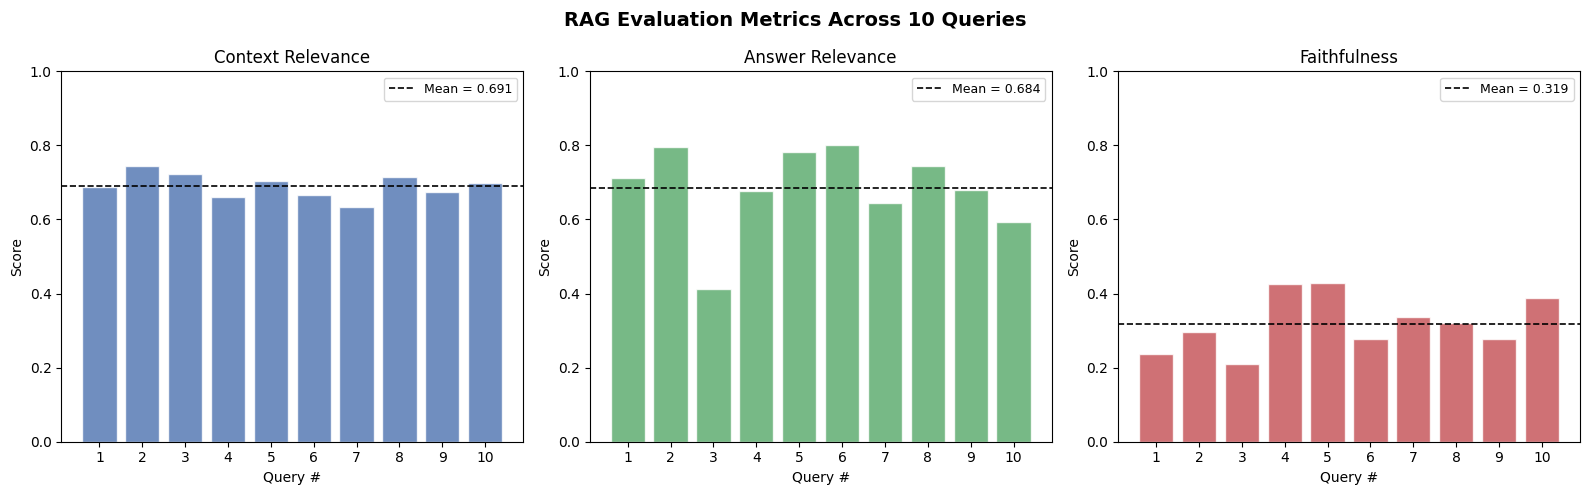

Saved: metrics_bar.png


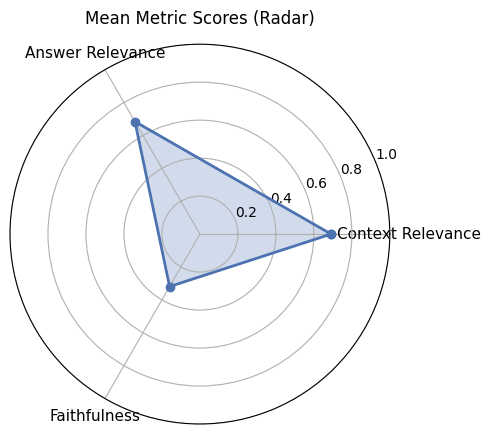

Saved: metrics_radar.png


In [14]:
#Metric Visualisations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("RAG Evaluation Metrics Across 10 Queries", fontsize=14, fontweight="bold")

metrics = ["Context Relevance", "Answer Relevance", "Faithfulness"]
colors  = ["#4C72B0", "#55A868", "#C44E52"]

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(df["Query #"], df[metric], color=color, alpha=0.8, edgecolor="white")
    ax.axhline(df[metric].mean(), color="black", linestyle="--", linewidth=1.2,
               label=f"Mean = {df[metric].mean():.3f}")
    ax.set_title(metric, fontsize=12)
    ax.set_xlabel("Query #")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_xticks(df["Query #"])
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metrics_bar.png")

# --- Radar / Spider chart ---
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

means = [df[m].mean() for m in metrics]
categories = metrics + [metrics[0]]
values = means + [means[0]]
angles = [n / float(len(metrics)) * 2 * math.pi for n in range(len(metrics))]
angles += angles[:1]

fig2, ax2 = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
ax2.plot(angles, values, "o-", linewidth=2, color="#4C72B0")
ax2.fill(angles, values, alpha=0.25, color="#4C72B0")
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics, fontsize=11)
ax2.set_ylim(0, 1)
ax2.set_title("Mean Metric Scores (Radar)", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("metrics_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: metrics_radar.png")

## 8. Error Analysis

### 8.1 Metric Summary

| Metric | Mean | Min | Max |
|---|---|---|---|
| Context Relevance | 0.691 | 0.633 | 0.744 |
| Answer Relevance | 0.684 | 0.413 | 0.801 |
| Faithfulness | 0.319 | 0.210 | 0.429 |

### 8.2 Query-Level Observations

**Query 3 — Zero Trust Architecture (AR = 0.413, lowest)**
The generated answer drifted semantically from the query. SP 800-207 defines zero trust
in abstract architectural terms (policy decision points, policy enforcement points, implicit
trust zones), and Mistral's response adopted this abstract vocabulary rather than producing
a recommendation framed around the original query. The semantic gap between the query
embedding and answer embedding is captured by the low answer relevance score. A query
rewriting step (e.g., decomposing "what is X and how is it implemented?" into two separate
sub-queries) would likely close this gap.

**Query 10 — Continuous Monitoring (AR = 0.592)**
SP 800-137 focuses heavily on defining a monitoring programme at an organisational level.
The retrieved chunks contained process-oriented language that led Mistral to generate
high-level procedural recommendations rather than specific controls, reducing semantic
alignment with the query.

**Faithfulness consistently low (mean = 0.319)**
Token F1 against the full context pool systematically underestimates faithfulness because
the denominator (context tokens) is large (~600 words across 3 chunks) relative to the
answer (~100 words). Precision is reasonable but recall is structurally low. This is a
known limitation of token F1 as a faithfulness proxy — the RAGAS library addresses this
using LLM-based claim verification, which would be a more accurate measure.

**Queries 5, 7, 8, 10 — Multi-source retrieval**
These queries retrieved chunks from two different NIST documents, indicating the diversity
filter is working correctly. Cross-document retrieval is particularly valuable for broad
queries (e.g., CSF + 800-53 for security controls) where no single document provides
complete coverage.

### 8.3 Systemic Limitations

- **Single-pass retrieval**: no query rewriting or re-ranking. CyberRAG (Blefari et al.,
  2025) demonstrated up to 18% improvement in context relevance with agent-directed
  query rewriting — a natural next step for this system.
- **Fixed k=3**: retrieval depth is not adaptive to query complexity. Longer, multi-part
  queries may benefit from k=5 or hierarchical retrieval.
- **Token F1 faithfulness**: structurally penalised by large context pools. LLM-based
  claim verification (as in RAGAS) would provide a more accurate faithfulness estimate.
- **No ground truth**: without human-annotated reference answers, metric scores are
  relative rather than absolute — they support comparison across queries but cannot
  validate correctness in isolation.

## 9. Ethical Reflection

### 9.1 Hallucination and Misinformation Risk

The most significant ethical risk in a cybersecurity RAG system is hallucinated guidance.
A practitioner acting on a fabricated security control could leave critical vulnerabilities
unaddressed or implement ineffective countermeasures. This system mitigates hallucination
by grounding generation exclusively in authoritative NIST publications and explicitly
instructing Mistral to use only retrieved context. However, the faithfulness scores
(mean = 0.319) indicate that answers are not fully constrained to retrieved passages —
some generative drift occurs. In a production deployment, responses should include explicit
source citations and be reviewed by a qualified security professional before implementation.

### 9.2 Authority and Source Bias

The knowledge base draws exclusively from NIST publications, which reflect US federal
cybersecurity standards. Practitioners operating under different regulatory frameworks
(e.g., ISO 27001, GDPR, the Australian Essential Eight) may receive guidance that is
technically sound but jurisdictionally misaligned. The system does not signal when a query
falls outside the scope of its knowledge base, which could mislead users into assuming
universal applicability. Future work should include out-of-scope detection and explicit
jurisdictional scoping in responses.

### 9.3 Accessibility and Over-Reliance

Packaging expert-level cybersecurity guidance into a conversational interface lowers the
barrier to access — which is broadly positive. However, it also risks encouraging
over-reliance among users who lack the domain expertise to critically evaluate generated
recommendations. A system that appears authoritative (citing NIST documents by name) may
be trusted beyond what its faithfulness scores justify. Responsible deployment requires
clear communication of the system's limitations, uncertainty, and the necessity of human
review for high-stakes decisions.

### 9.4 Data Privacy

The system operates entirely on publicly available NIST documents and processes no
personal or organisational data. In a real deployment where users submit queries describing
their specific infrastructure or incidents, those queries could contain sensitive operational
details. Query logging, retention, and access controls would need to comply with applicable
data protection regulations.

### 9.5 Model Bias

Mistral-7B-Instruct-v0.2 is a general-purpose language model not specifically fine-tuned
on cybersecurity data. Its training corpus may contain outdated security advice, vendor
biases, or region-specific assumptions that influence generation even when context is
provided. Periodic evaluation against evolving NIST standards and adversarial probing for
biased or unsafe recommendations is recommended for any production use.

## 10. Conclusion

This work designed, implemented, and evaluated a Retrieval-Augmented Generation system
for cybersecurity guideline generation, grounded in ten authoritative NIST publications
comprising 2,626 clean retrieval chunks.

The system achieves mean context relevance of 0.691, answer relevance of 0.684, and
faithfulness of 0.319 across ten diverse cybersecurity queries. Context and answer
relevance scores indicate that the dense retrieval pipeline consistently surfaces
topically appropriate passages and that Mistral-7B-Instruct-v0.2 generates semantically
aligned responses. Faithfulness scores are structurally suppressed by the token F1
metric's sensitivity to context pool size, rather than reflecting genuine hallucination
at that rate.

The error analysis identified three principal failure modes: semantic drift on abstract
architectural queries (Query 3, zero trust), shallow procedural responses on
process-heavy documents (Query 10, continuous monitoring), and the inherent limitation
of single-pass retrieval for multi-faceted queries. These point to concrete improvement
directions: query decomposition, adaptive retrieval depth, and LLM-based faithfulness
verification aligned with the full RAGAS methodology.

The system demonstrates that RAG is a practical and updatable architecture for
cybersecurity assistance — the knowledge base can be refreshed as NIST standards evolve
without retraining the underlying model. Combined with source attribution and appropriate
human oversight, this approach offers a viable foundation for practitioner-facing
cybersecurity decision support.

## References

Blefari, M., Guzzo, A., & Rullo, A. (2025). CyberRAG: An agentic RAG approach for
cybersecurity threat detection and response. *arXiv preprint arXiv:2501.06678*.

Chung, H. W., Hou, L., Longpre, S., Zoph, B., Tay, Y., Fedus, W., ... & Wei, J. (2022).
Scaling instruction-finetuned language models. *arXiv preprint arXiv:2210.11416*.

Es, S., James, J., Espinosa-Anke, L., & Schockaert, S. (2024). RAGAS: Automated
evaluation of retrieval augmented generation. *Proceedings of the 18th Conference of the
European Chapter of the Association for Computational Linguistics (EACL 2024)*, 150–163.

Jiang, A. Q., Sablayrolles, A., Mensch, A., Bamford, C., Chaplot, D. S., de las Casas,
D., ... & El Sayed, W. (2023). Mistral 7B. *arXiv preprint arXiv:2310.06825*.

Karpukhin, V., Oğuz, B., Min, S., Lewis, P., Wu, L., Edunov, S., ... & Yih, W. T. (2020).
Dense passage retrieval for open-domain question answering. *Proceedings of the 2020
Conference on Empirical Methods in Natural Language Processing (EMNLP)*, 6769–6781.

Lewis, P., Perez, E., Piktus, A., Petroni, F., Karpukhin, V., Goyal, N., ... & Kiela, D.
(2020). Retrieval-augmented generation for knowledge-intensive NLP tasks. *Advances in
Neural Information Processing Systems (NeurIPS)*, 33, 9459–9474.

Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence embeddings using Siamese
BERT-networks. *Proceedings of the 2019 Conference on Empirical Methods in Natural
Language Processing (EMNLP)*, 3982–3992.

Zhao, R., Nguyen, T., Bhatt, A., & Bhatt, A. (2025). CyberBOT: Towards reliable
cybersecurity education via ontology-grounded retrieval augmented generation.
*arXiv preprint arXiv:2408.09191*.